<a href="https://colab.research.google.com/github/a-brhian/Design_Of_Experiments.pt/blob/main/02_Analise_de_Variancia_(ANOVA)_com_Interacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#-------------------------------------------
# INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNOLOGIA DO AMAZONAS
#
# CREATED BY: SANDRA VIANA CÁD E ALYSSON BRHIAN
# DATA: 12/03/2012
# VERSION OF R: 4.6.0
#
# GOAL: Analise de Variancia (ANOVA) com Interacao
# R.version.string
#---------------------------------------------

Esses são os pacotes que estão sendo utiliados neste código:

In [58]:
library(ggplot2)
library(dplyr)

#install.packages(c("car", "tidyverse", "ExpDes.pt", "emmeans", "multcompView", "multcomp"))
library(car) # Para Levene's Test
library(tidyverse)
library(ExpDes.pt) # Pacote para análise de experimentos
library(emmeans) # Para médias marginais estimadas e comparações múltiplas
library(multcompView) # Para visualização compacta de comparações múltiplas
library(multcomp) # Necessário para a função cld com emmeans

#Análise de Variância (ANOVA)

## Introdução ao problema

Em uma indústria fabricante de equipamentos eletrônicos, uma furadeira era utilizada para furar as placas de circuito impresso produzidas. O processo de
furação estava sob controle estatístico mas o fabricante considerava que existia muita variabilidade. Com o objetivo de reduzir a variabilidade do processo foi realizado um experimento com dois fatores:

> (1) velocidade de rotação (40, 60 e 80 rpm) e

> (2) diâmetro da broca (1/16, 1/12 e 1/8 polegadas).

Como era difícil medir diretamente a variação no diâmetro dos furos, foi medido a vibração que ocorria na superfície da placa. Os resultados obtidos estão apresentados na tabela a seguir.



In [59]:
# Fatores
velocidade <- factor(rep(c(40,60,80), each = 12))
diametro <- factor(rep(rep(c("1/16","1/12","1/8"), each = 4), times = 3))

# Respostas (vibração)

vibracao <- c(
  # 40 rpm
  10.6, 13.7, 16.8, 16.6,
  11.2, 12.3, 16.1, 12.3,
  24.5, 21.3, 19.9, 18.4,

  # 60 rpm
  14.8, 14.7, 16.8, 11.2,
  22.8, 22.8, 23.6, 24.6,
  24.3, 26.3, 30.0, 26.6,

  # 80 rpm
  17.1, 12.0, 14.6, 15.4,
  21.3, 23.4, 27.3, 23.6,
  31.6, 35.5, 28.9, 31.9
)

dados <- data.frame(velocidade, diametro, vibracao)

# Visualizao dos primeiros e ultimos dados
head(dados);tail(dados)


,velocidade,diametro,vibracao
,<fct>,<fct>,<dbl>
1,40,1/16,10.6
2,40,1/16,13.7
3,40,1/16,16.8
4,40,1/16,16.6
5,40,1/12,11.2
6,40,1/12,12.3


,velocidade,diametro,vibracao
,<fct>,<fct>,<dbl>
31,80,1/12,27.3
32,80,1/12,23.6
33,80,1/8,31.6
34,80,1/8,35.5
35,80,1/8,28.9
36,80,1/8,31.9


## Análise Descritiva

Antes de partir para ANOVA, vamos visualizar sobre como os dados coletados, em média, se apresentaram:

In [60]:
# Médias por grupo
aggregate(vibracao ~ velocidade + diametro, data = dados, mean)

velocidade,diametro,vibracao
<fct>,<fct>,<dbl>
40,1/12,12.975
60,1/12,23.450
80,1/12,23.900
40,1/16,14.425
60,1/16,14.375
80,1/16,14.775
40,1/8,21.025
60,1/8,26.800
80,1/8,31.975


Uma melhor visualização é feita por meio do gráfico de *boxplot*:

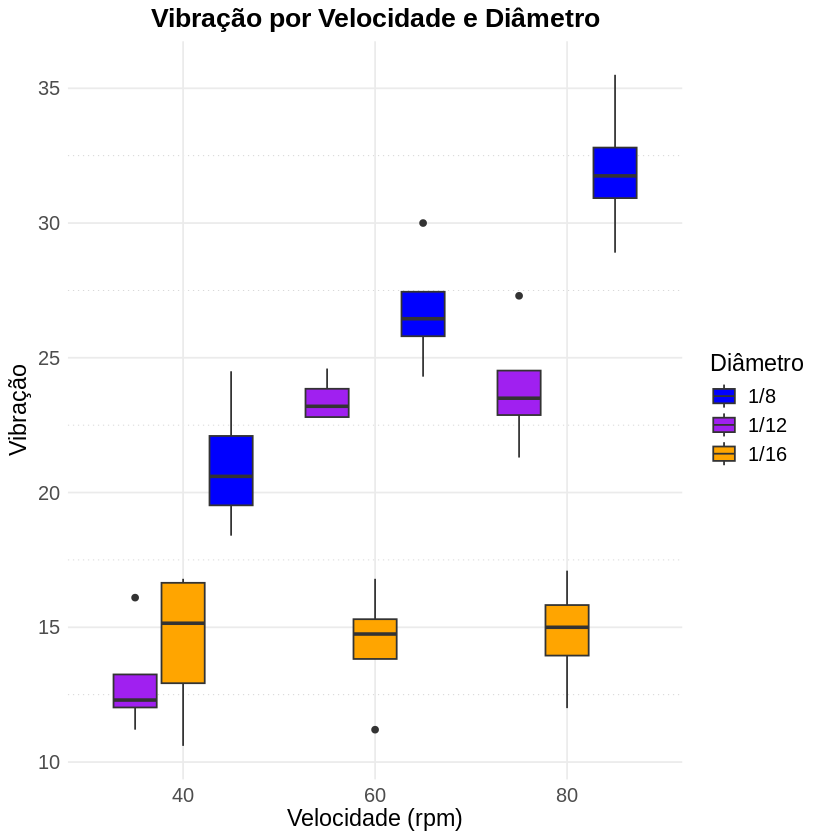

In [61]:
ggplot(dados, aes(x = velocidade, y = vibracao, fill = diametro)) +
  geom_boxplot() +
  labs(title = "Vibração por Velocidade e Diâmetro", x = "Velocidade (rpm)", y = "Vibração") +
  scale_fill_manual(
    name = "Diâmetro",
    values = c("1/16" = "orange", "1/12" = "purple", "1/8" = "blue"),
    breaks = c("1/8", "1/12", "1/16") # Set legend order
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5), # Bold and centered title
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    panel.grid.minor.x = element_line(color = "lightgray", linetype = "dotted"), # Secondary horizontal grid
    panel.grid.minor.y = element_line(color = "lightgray", linetype = "dotted")  # Secondary vertical grid
  )

Os dados mostram que furadeiras com brocas maiores tendem a ter vibrações maiores, enquanto que as furadeiras com brocas menores tendem a ter vibrações menores. Porém, uma furadeira com diâmentro "intermediário" de 1/12 e velocidade de 40 rpm, apresentou vibração menores que as de menor diâmetro.

Para verificar melhor essa característica, vamos analisar o gráfico de interação:

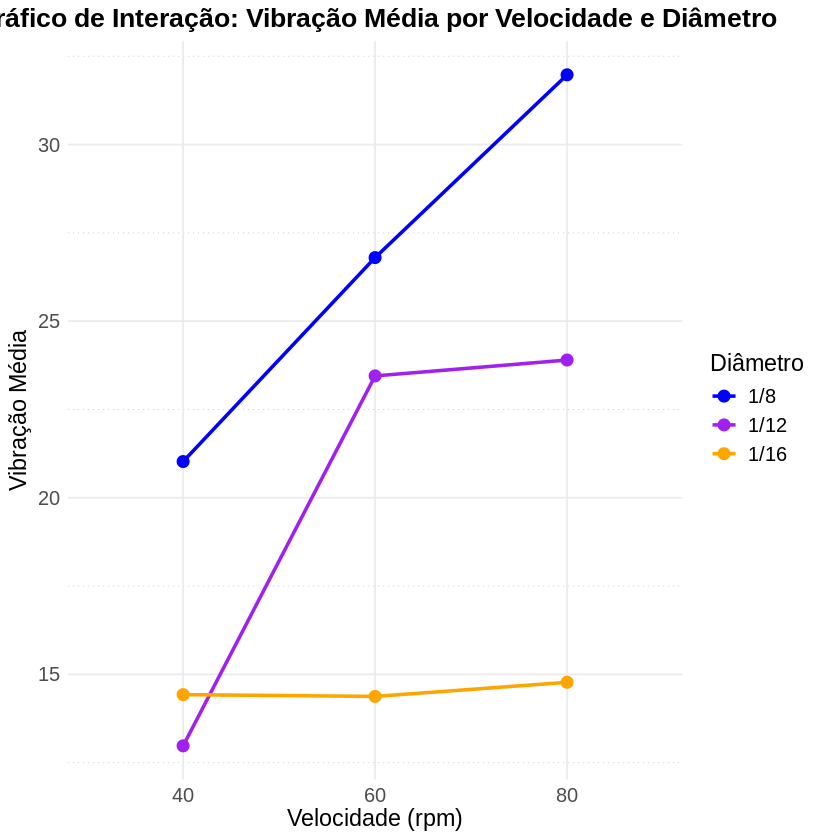

In [62]:
# Calculate means for interaction plot
mean_vibracao <- dados %>%
  group_by(velocidade, diametro) %>%
  summarise(mean_vibracao = mean(vibracao), .groups = "drop") %>%
  ungroup()

# Gráfico de Interação com ggplot2
ggplot(mean_vibracao, aes(x = velocidade, y = mean_vibracao, group = diametro, color = diametro)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  labs(
    title = "Gráfico de Interação: Vibração Média por Velocidade e Diâmetro",
    x = "Velocidade (rpm)",
    y = "Vibração Média"
  ) +
  scale_color_manual(
    name = "Diâmetro",
    values = c("1/16" = "orange", "1/12" = "purple", "1/8" = "blue"),
    breaks = c("1/8", "1/12", "1/16") # Set legend order
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5), # Bold and centered title
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    panel.grid.minor.x = element_line(color = "lightgray", linetype = "dotted"), # Secondary horizontal grid
    panel.grid.minor.y = element_line(color = "lightgray", linetype = "dotted")  # Secondary vertical grid
  )

O que mostra de forma mais clara, a menor vibração que ocorre quando se usa uma furadeira com diâmetro "intermediário" de 1/12 e uma baixa velocidade de 40 rpm. Esse gráfico, por não ter linhas paralelas indica uma potencial interação entre velocidade e vibração.

Agora, por meio da ANOVA, vamos verificar se existe um efeito de interação significativo entre velocidade e diâmetro na variável de vibração.

## Modelo Estatístico

O modelo adequado é um fatorial completo de dois fatores com interação:

$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \epsilon_{ijk}$$

Onde:

* $Y_{ijk}$ é a vibração observada na $k$-ésima réplica, para o * $i$-ésimo nível de Velocidade e $j$-ésimo nível de Diâmetro;
* $\mu$ é a média geral;
* $\alpha_i$ é o efeito do $i-$ésimo nível de Velocidade;
* $\beta_j$ é o efeito do $j$-ésimo nível de Diâmetro da broca;
* $(\alpha\beta)_{ij}$ é o efeito da interação entre o $i$-ésimo nível de Velocidade e $j$-ésimo nível de Diâmetro;
* $\epsilon_{ijk} \sim i.i.d. N(0, \sigma^2)$ é o erro aleatório experimental.

No `R`, esse modelo é escrito como:

In [63]:
# Ajuste do modelo
modelo <- aov(vibracao ~ velocidade * diametro, data = dados)

Porém, antes disso é importante testar as suposições dos dados de:

1. Normalidade nos resíduos
2. Homocedasticidade
3. Independência nas medidas

A normalidade nos resíduos é feita por meio dos seguinte teste:

In [64]:
shapiro.test(residuals(modelo))


	Shapiro-Wilk normality test

data:  residuals(modelo)
W = 0.94565, p-value = 0.07633


Como a hipótese nula é de que os dados são normais, então ao nível de significância de 5%, os dados apresentam evidências de não rejeição da hipótese nula, isto é, os resídos aparentam características de serem oriundas de uma distribuição normal.

A suposição de homocedastividade nos resíduos, pode ser feita por meio do seguinte teste:

In [65]:
leveneTest(vibracao ~ velocidade * diametro, data = dados)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,8,0.3246568,0.949297
,27,NA,NA


A hipótese nula do teste de Levene é que as variâncias dos dados são homocedasticas, e segundo esse teste, ao nível de significância de 5%, os dados não rejeitam essa hipótese nula, ou seja, os dados apresentam evidências de homocedasticidade.

O código a seguir, mostra dois gráficos onde, o da esquerda, ajuda a verificar a independência dos resíduos e o gráfico da direita, ajuda a verificar se os dados se ajustam a reta linear, isto é, se se aproximam de uma distribuição normal:

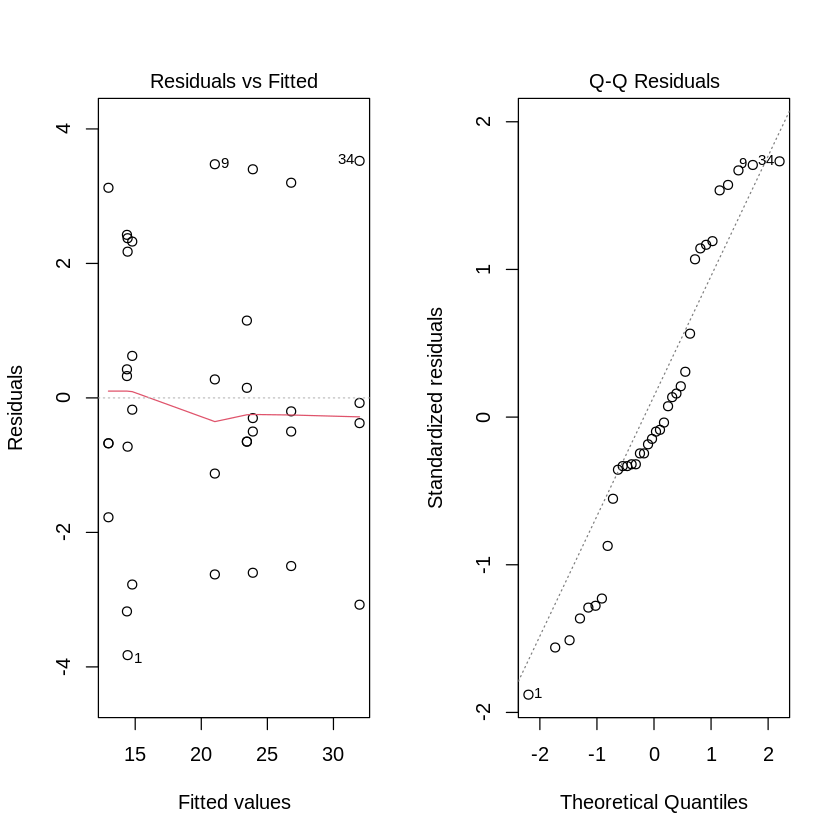

In [66]:
par(mfrow = c(1, 2))
plot(modelo, which = 1:2)

O gráfico da esquerda mostra independência nos resíduos, já que não há nenhuma tendência aparente. E o gráfico da direita mostra que os resíduos aparentam serem oriundas de uma distribuição normal.

Como o modelo passou nos três pressupostos, então podemos prosseguir com a ANOVA. A tabela da ANOVA é:

In [67]:
anova_result <- summary(modelo)
anova_result

                    Df Sum Sq Mean Sq F value   Pr(>F)    
velocidade           2  352.3   176.2  31.900 7.75e-08 ***
diametro             2  876.5   438.2  79.362 4.94e-12 ***
velocidade:diametro  4  193.8    48.5   8.775 0.000113 ***
Residuals           27  149.1     5.5                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Segue a explicação da tabela ANOVA:

- **Df (Graus de Liberdade):**  
  Representa o número de informações independentes utilizadas para calcular uma estatística. Para os fatores, normalmente corresponde ao número de níveis menos 1. Para os resíduos, está relacionado ao número total de observações menos o número de parâmetros estimados.

- **Sum Sq (Soma dos Quadrados):**  
  Mede a variação total atribuída a cada fator ou ao termo de erro.

- **Mean Sq (Quadrado Médio):**  
  É a Soma dos Quadrados dividida pelos Graus de Liberdade. Representa a variância explicada por cada fonte.

- **F value (Estatística F):**  
  É a razão entre o Quadrado Médio de um fator e o Quadrado Médio dos resíduos. Um valor elevado de F indica que a variação explicada pelo fator é maior do que a variação não explicada (erro).

- **Pr(>F) (valor-p):**  
  Representa a probabilidade de observar uma estatística F tão extrema quanto a calculada, assumindo que a hipótese nula seja verdadeira (isto é, que o fator não possui efeito). Um valor-p pequeno (tipicamente menor que 0,05) sugere que o fator possui efeito estatisticamente significativo.


Essa é a interpretação dos Resultados:

Analisando a coluna **Pr(>F)**:

- velocidade: O valor-p para **velocidade** é `0.000109`. Como esse valor é muito menor que `0,05` (e até mesmo menor que `0,01`), rejeita-se a hipótese nula. Logo, existe um efeito estatisticamente significativo da velocidade sobre a vibração. Diferentes velocidades produzem níveis significativamente diferentes de vibração.

- diametro: O valor-p para **diametro** é `1.21e-07` (equivalente a `0.000000121`). Esse valor também é muito menor que `0,05`. Assim, existe um efeito estatisticamente significativo do diâmetro sobre a vibração. Diferentes diâmetros de broca produzem níveis significativamente diferentes de vibração.

- velocidade:diametro (Interação entre Velocidade e Diâmetro): O valor-p para o termo de interação é `0.000115`. Esse valor também é muito menor que `0,05`. Dessa forma, existe um efeito de interação estatisticamente significativo entre velocidade e diâmetro sobre a vibração. Isso significa que o efeito da velocidade na vibração depende do diâmetro utilizado, e vice-versa. Esse resultado confirma o que foi observado pelas linhas não paralelas no gráfico de interação.


Todos os três fatores — **velocidade**, **diametro** e a **interação entre eles** — são estatisticamente significativos para explicar a variação da vibração.

A interação significativa é particularmente importante, pois indica que os efeitos da velocidade e do diâmetro não podem ser analisados de forma independente; o efeito combinado entre eles não é simplesmente aditivo.

O próximo passo é verificarmos quais são as combinações dos tratamentos que tem comportamento parecido por meio do teste de Tukey.

# Teste de Tukey

Para verificarmos quais tratamentos são parecidos entre si ao nível de significancia de 5%, podes usar os seguintes códigos:

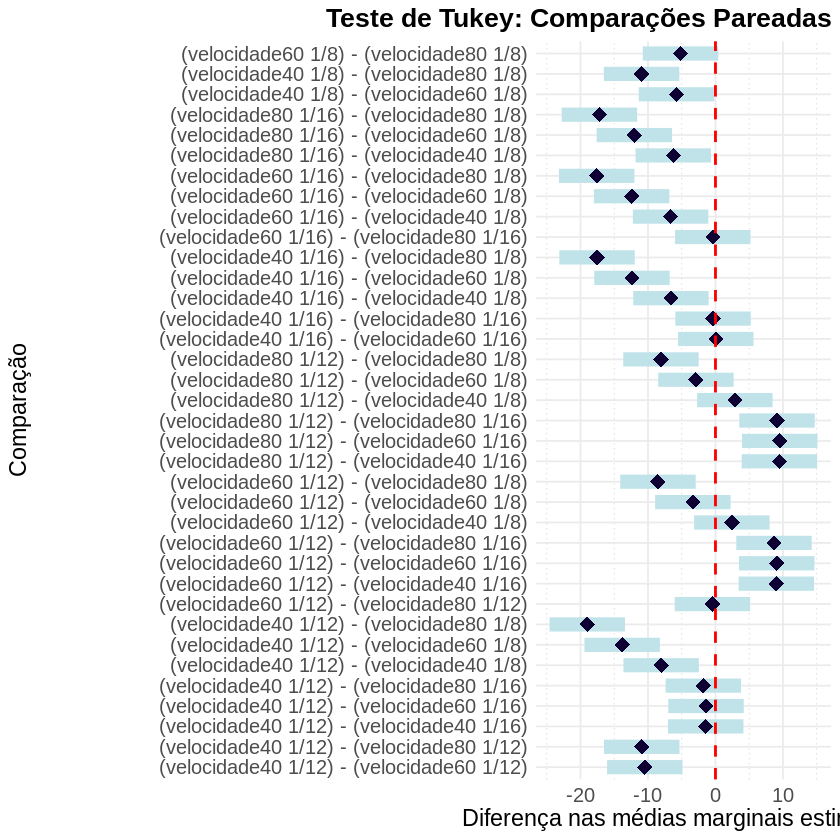

In [68]:
# 1. Calcular as médias marginais estimadas para a interação completa
em_interaction <- emmeans(modelo, ~ velocidade * diametro)

# 2. Realizar as comparações pareadas usando o ajuste de Tukey (padrão no emmeans)
pairwise_results <- pairs(em_interaction, adjust = "tukey")

# 3. Gerar o gráfico das comparações pareadas, aplicando estilos ggplot2
p <- plot(pairwise_results,
     ylab = "Comparação",
     xlab = "Diferença nas médias marginais estimadas") + # Removido 'main' daqui
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 0.8) + # Linha de referência em zero
  theme_minimal() +
  labs(title = "Teste de Tukey: Comparações Pareadas para a Interação") + # Adicionado 'labs' para o título
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5), # Título em negrito e centralizado
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    panel.grid.minor.x = element_line(color = "lightgray", linetype = "dotted"),
    panel.grid.minor.y = element_line(color = "lightgray", linetype = "dotted")
  )

# Exibir o gráfico
print(p)

# Opcional: para ver os valores p e intervalos de confiança na tabela
# summary(pairwise_results)

Uma melhor maneira de visitar essas comparações é atribuindo letras paras as comparações que aparentam as mesmas semelhanças:

In [69]:
# Letras para a INTERAÇÃO
letras <- multcompLetters4(modelo, diferenca)

letras

$velocidade
 80  60  40 
"a" "a" "b" 

$diametro
 1/8 1/12 1/16 
 "a"  "b"  "c" 

$`velocidade:diametro`
 80:1/8  60:1/8 80:1/12 60:1/12  40:1/8 80:1/16 40:1/16 60:1/16 40:1/12 
    "a"    "ab"    "bc"    "bc"     "c"     "d"     "d"     "d"     "d" 


Com base nas médias e nos gráficos, a combinação que produz a menor vibração é a velocidade 40 rpm com diâmetro 1/16 pol (ou possivelmente 1/12 pol, dependendo do teste de Tukey).